In [1]:
import pandas as pd
import requests
import os
from tqdm import tqdm

# Upload CSV in Colab
from google.colab import files
uploaded = files.upload()

csv_file = list(uploaded.keys())[0]

df = pd.read_csv(csv_file)
df.head()

Saving myntra_assignment_dataset.csv to myntra_assignment_dataset.csv


,product_url,image_url,gender,sleeve_type
0,https://www.myntra.com/tshirts/nautica/nautica...,"https://assets.myntassets.com/h_720,q_90,w_540...",male,full sleeve
1,https://www.myntra.com/tshirts/sztori/sztori-m...,"https://assets.myntassets.com/h_720,q_90,w_540...",male,full sleeve
2,https://www.myntra.com/tshirts/szn/szn-men-pol...,"https://assets.myntassets.com/h_720,q_90,w_540...",male,full sleeve
3,https://www.myntra.com/tshirts/highlander/high...,"https://assets.myntassets.com/h_720,q_90,w_540...",male,full sleeve
4,https://www.myntra.com/tshirts/the+modern+soul...,"https://assets.myntassets.com/h_720,q_90,w_540...",male,full sleeve


In [2]:
import pandas as pd
import requests
import os
from tqdm import tqdm

# Load your master CSV
df = pd.read_csv('myntra_assignment_dataset.csv')

def prepare_data(df, column_name, base_folder):
    print(f"🚀 Preparing {base_folder}...")
    for i, row in tqdm(df.iterrows(), total=len(df)):
        label = str(row[column_name]).lower().replace(" ", "_").strip()
        target_folder = os.path.join(base_folder, label)
        os.makedirs(target_folder, exist_ok=True)

        img_path = os.path.join(target_folder, f"img_{i}.jpg")
        if not os.path.exists(img_path):
            try:
                img_data = requests.get(row['image_url'], timeout=5).content
                with open(img_path, 'wb') as f:
                    f.write(img_data)
            except: continue

# Create two separate folder structures
prepare_data(df, 'gender', 'gender_dataset')
prepare_data(df, 'sleeve_type', 'sleeve_dataset')

🚀 Preparing gender_dataset...


100%|██████████| 220/220 [00:05<00:00, 41.16it/s]


🚀 Preparing sleeve_dataset...


100%|██████████| 220/220 [00:04<00:00, 44.66it/s]


In [8]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def train_fashion_model(data_dir, model_name):
    print(f"\n--- Training {model_name} Model ---")

    # Data Augmentation to fix low accuracy
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2,
        rotation_range=20,
        horizontal_flip=True,
        zoom_range=0.2
    )

    train = datagen.flow_from_directory(data_dir, target_size=(224,224), batch_size=16, subset='training')
    valid = datagen.flow_from_directory(data_dir, target_size=(224,224), batch_size=16, subset='validation', shuffle=False)

    # Model Architecture
    base = MobileNet(weights='imagenet', include_top=False)
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    output = Dense(train.num_classes, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=output)

    # Freeze base
    for layer in base.layers:
        layer.trainable = False

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(train, validation_data=valid, epochs=15)
    model.save(f'{model_name}_model.h5')
    return model, train.class_indices

# Train both
gender_model, gender_labels = train_fashion_model('gender_dataset', 'gender')
sleeve_model, sleeve_labels = train_fashion_model('sleeve_dataset', 'sleeve')


--- Training gender Model ---
Found 176 images belonging to 2 classes.
Found 44 images belonging to 2 classes.


/tmp/ipykernel_5230/436316905.py:23: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNet(weights='imagenet', include_top=False)


Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6250 - loss: 1.1810 - val_accuracy: 0.8182 - val_loss: 0.4229
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9091 - loss: 0.2103 - val_accuracy: 0.9545 - val_loss: 0.1700
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9716 - loss: 0.0837 - val_accuracy: 0.8864 - val_loss: 0.2710
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9659 - loss: 0.0844 - val_accuracy: 0.9773 - val_loss: 0.1028
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9886 - loss: 0.0373 - val_accuracy: 0.9773 - val_loss: 0.0721
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0199 - val_accuracy: 1.0000 - val_loss: 0.0369
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0389
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.9773 - val_loss:


--- Training sleeve Model ---
Found 176 images belonging to 2 classes.
Found 44 images belonging to 2 classes.
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5795 - loss: 0.9683 - val_accuracy: 0.7955 - val_loss: 0.5078
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8920 - loss: 0.2831 - val_accuracy: 0.9318 - val_loss: 0.1884
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9545 - loss: 0.1755 - val_accuracy: 0.7727 - val_loss: 0.5669
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9205 - loss: 0.1562 - val_accuracy: 0.8409 - val_loss: 0.3927
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9830 - loss: 0.0673 - val_accuracy: 0.9091 - val_loss: 0.3036
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9886 - loss: 0.0624 - val_accuracy: 0.9545 - val_loss: 0.1723
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0413 - val_accuracy: 0.9545 - val_loss: 0.1448
Epoch 

KeyboardInterrupt: 

Found 44 images belonging to 2 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


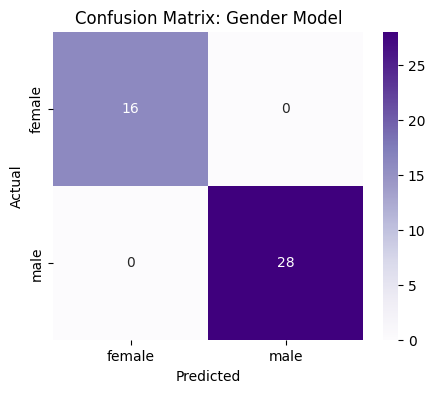


--- Gender Model Classification Report ---
              precision    recall  f1-score   support

      female       1.00      1.00      1.00        16
        male       1.00      1.00      1.00        28

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44

Found 44 images belonging to 2 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 945ms/step


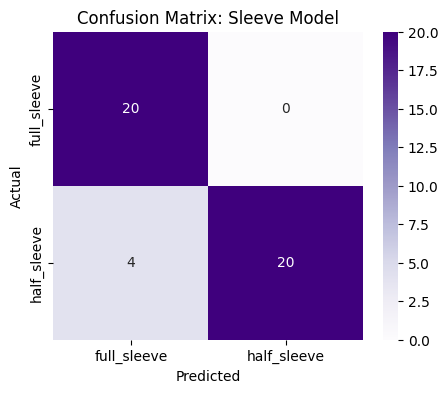


--- Sleeve Model Classification Report ---
              precision    recall  f1-score   support

 full_sleeve       0.83      1.00      0.91        20
 half_sleeve       1.00      0.83      0.91        24

    accuracy                           0.91        44
   macro avg       0.92      0.92      0.91        44
weighted avg       0.92      0.91      0.91        44



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_dual_matrices(model, data_dir, title):
    # 1. Setup Validation Generator (Non-shuffled for evaluation)
    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
    eval_gen = eval_datagen.flow_from_directory(
        data_dir,
        target_size=(224, 224),
        batch_size=16,
        subset='validation',
        shuffle=False
    )

    # 2. Predict
    preds = model.predict(eval_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = eval_gen.classes
    class_names = list(eval_gen.class_indices.keys())

    # 3. Plot Heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print(f"\n--- {title} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Execute for both models
plot_dual_matrices(gender_model, 'gender_dataset', 'Gender Model')
plot_dual_matrices(sleeve_model, 'sleeve_dataset', 'Sleeve Model')

In [6]:
import gradio as gr
import numpy as np

def dual_predict(input_img):
    if input_img is None: return "N/A", "N/A"

    # Preprocess
    img = tf.image.resize(input_img, (224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img).copy()
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Prediction 1: Gender
    g_preds = gender_model.predict(img_array)
    g_idx = np.argmax(g_preds[0])
    g_label = list(gender_labels.keys())[g_idx]

    # Prediction 2: Sleeve
    s_preds = sleeve_model.predict(img_array)
    s_idx = np.argmax(s_preds[0])
    s_label = list(sleeve_labels.keys())[s_idx]

    return g_label.upper(), s_label.upper().replace("_", " ")

demo = gr.Interface(
    fn=dual_predict,
    inputs=gr.Image(),
    outputs=[gr.Textbox(label="Gender Prediction"), gr.Textbox(label="Sleeve Prediction")],
    title="Dual-Model Fashion Classifier"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b9bf0a302ef9143ed7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
